# Customer Churn Prediction Using Machine Learning

### Predicting Customer Attrition with Supervised Learning

---

**Project Type:** Binary Classification  
**Dataset:** IBM Telco Customer Churn  
**Models:** Logistic Regression · Decision Tree · Random Forest

> An end-to-end machine learning project focused on identifying customers
> who are likely to churn and understanding the factors driving customer attrition.


In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Visualization defaults
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [6]:
from pathlib import Path

# Path to the raw dataset
DATA_PATH = Path("../data/raw/Telco-Customer-Churn.csv")

# Load dataset
df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print(f"Dataset shape: {df.shape}")

Dataset loaded successfully.
Dataset shape: (7043, 21)


In [7]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [9]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [11]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [12]:
print(df["Churn"].value_counts())

print("\nChurn percentage:")
print(df["Churn"].value_counts(normalize=True).mul(100).round(2))

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn percentage:
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


In [13]:
print("Data types:")
print(df.dtypes)

Data types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [14]:
print("\nUnique values in each column:")
print(df.nunique())


Unique values in each column:
customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64


In [15]:
print("\nColumn names:")
print(df.columns.tolist())


Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [16]:
print("Blank TotalCharges values:")
print((df["TotalCharges"].str.strip() == "").sum())

Blank TotalCharges values:
11


In [17]:
print("\nSample blank TotalCharges rows:")
print(df[df["TotalCharges"].str.strip() == ""][["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]])


Sample blank TotalCharges rows:
      customerID  tenure  MonthlyCharges TotalCharges Churn
488   4472-LVYGI       0           52.55                 No
753   3115-CZMZD       0           20.25                 No
936   5709-LVOEQ       0           80.85                 No
1082  4367-NUYAO       0           25.75                 No
1340  1371-DWPAZ       0           56.05                 No
3331  7644-OMVMY       0           19.85                 No
3826  3213-VVOLG       0           25.35                 No
4380  2520-SGTTA       0           20.00                 No
5218  2923-ARZLG       0           19.70                 No
6670  4075-WKNIU       0           73.35                 No
6754  2775-SEFEE       0           61.90                 No


In [18]:
print("\nTotalCharges data type before conversion:")
print(df["TotalCharges"].dtype)


TotalCharges data type before conversion:
object


In [19]:
print("Blank TotalCharges with non-zero tenure:")
print(
    df[
        (df["TotalCharges"].str.strip() == "") &
        (df["tenure"] != 0)
    ][["customerID", "tenure", "MonthlyCharges", "TotalCharges"]]
)

Blank TotalCharges with non-zero tenure:
Empty DataFrame
Columns: [customerID, tenure, MonthlyCharges, TotalCharges]
Index: []


In [20]:
# Clean TotalCharges
df["TotalCharges"] = df["TotalCharges"].str.strip()
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Fill missing TotalCharges for customers with tenure = 0
df["TotalCharges"] = df["TotalCharges"].fillna(0)

print("TotalCharges cleaned successfully.")
print("Data type:", df["TotalCharges"].dtype)
print("Missing values:", df["TotalCharges"].isnull().sum())

TotalCharges cleaned successfully.
Data type: float64
Missing values: 0


In [21]:
# Drop customer ID
df = df.drop(columns=["customerID"])

print("customerID removed.")
print("New dataset shape:", df.shape)

customerID removed.
New dataset shape: (7043, 20)


In [22]:
print(df.columns.tolist())

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [23]:
# Separate features and target
X = df.drop(columns=["Churn"])
y = df["Churn"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

Features shape: (7043, 19)
Target shape: (7043,)

Target distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [24]:
# Identify categorical columns
categorical_cols = X.select_dtypes(include=["object"]).columns

print("Categorical columns:")
print(categorical_cols.tolist())

print("\nNumber of categorical columns:", len(categorical_cols))

Categorical columns:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Number of categorical columns: 15


In [25]:
# Display unique values
for col in categorical_cols:
    print(f"\n{col}:")
    print(X[col].unique())


gender:
['Female' 'Male']

Partner:
['Yes' 'No']

Dependents:
['No' 'Yes']

PhoneService:
['No' 'Yes']

MultipleLines:
['No phone service' 'No' 'Yes']

InternetService:
['DSL' 'Fiber optic' 'No']

OnlineSecurity:
['No' 'Yes' 'No internet service']

OnlineBackup:
['Yes' 'No' 'No internet service']

DeviceProtection:
['No' 'Yes' 'No internet service']

TechSupport:
['No' 'Yes' 'No internet service']

StreamingTV:
['No' 'Yes' 'No internet service']

StreamingMovies:
['No' 'Yes' 'No internet service']

Contract:
['Month-to-month' 'One year' 'Two year']

PaperlessBilling:
['Yes' 'No']

PaymentMethod:
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


In [26]:
# Identify numerical and categorical columns

numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical columns:")
print(numerical_cols)

print("\nCategorical columns:")
print(categorical_cols)

Numerical columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical columns:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).mul(100).round(2))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).mul(100).round(2))

Training set: (5634, 19)
Testing set: (1409, 19)

Training target distribution:
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

Testing target distribution:
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


In [28]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Preprocessing for numerical and categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [29]:
# Fit preprocessing on training data and transform it
X_train_processed = preprocessor.fit_transform(X_train)

# Transform test data using the already-fitted preprocessor
X_test_processed = preprocessor.transform(X_test)

print("Preprocessing completed successfully.")
print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Preprocessing completed successfully.
Processed training shape: (5634, 45)
Processed testing shape: (1409, 45)


In [30]:
# Encode target variable
y_train_encoded = y_train.map({"No": 0, "Yes": 1})
y_test_encoded = y_test.map({"No": 0, "Yes": 1})

print("Target encoding completed.")
print("\nTraining target:")
print(y_train_encoded.value_counts())

print("\nTesting target:")
print(y_test_encoded.value_counts())

Target encoding completed.

Training target:
Churn
0    4139
1    1495
Name: count, dtype: int64

Testing target:
Churn
0    1035
1     374
Name: count, dtype: int64


In [31]:
from sklearn.linear_model import LogisticRegression

# Create baseline model
baseline_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train model
baseline_model.fit(X_train_processed, y_train_encoded)

print("Baseline Logistic Regression trained successfully.")

Baseline Logistic Regression trained successfully.


In [32]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# Make predictions
y_pred = baseline_model.predict(X_test_processed)

# Probability predictions for ROC-AUC
y_prob = baseline_model.predict_proba(X_test_processed)[:, 1]

# Calculate evaluation metrics
accuracy = accuracy_score(y_test_encoded, y_pred)
precision = precision_score(y_test_encoded, y_pred)
recall = recall_score(y_test_encoded, y_pred)
f1 = f1_score(y_test_encoded, y_pred)
roc_auc = roc_auc_score(y_test_encoded, y_prob)

print("Baseline Logistic Regression Results")
print("------------------------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_encoded, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test_encoded, y_pred))

Baseline Logistic Regression Results
------------------------------------
Accuracy : 0.8055
Precision: 0.6572
Recall   : 0.5588
F1-Score : 0.6040
ROC-AUC  : 0.8421

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

Confusion Matrix:
[[926 109]
 [165 209]]


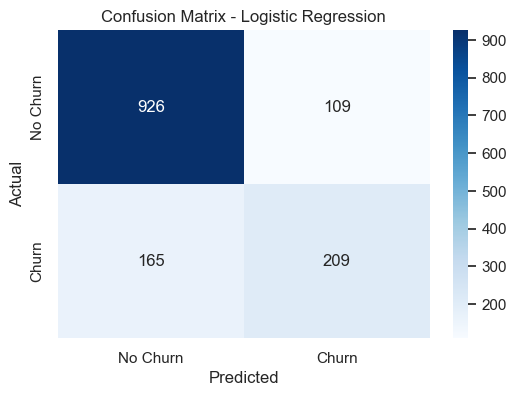

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test_encoded, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [34]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

# Test different probability thresholds
thresholds = np.arange(0.20, 0.61, 0.05)

print("Threshold | Precision | Recall | F1-Score")
print("-" * 45)

for threshold in thresholds:
    y_pred_threshold = (y_prob >= threshold).astype(int)

    precision = precision_score(y_test_encoded, y_pred_threshold, zero_division=0)
    recall = recall_score(y_test_encoded, y_pred_threshold, zero_division=0)
    f1 = f1_score(y_test_encoded, y_pred_threshold, zero_division=0)

    print(f"{threshold:.2f}      | {precision:.4f}    | {recall:.4f} | {f1:.4f}")

Threshold | Precision | Recall | F1-Score
---------------------------------------------
0.20      | 0.4672    | 0.8556 | 0.6043
0.25      | 0.4975    | 0.8102 | 0.6165
0.30      | 0.5193    | 0.7540 | 0.6150
0.35      | 0.5432    | 0.7059 | 0.6140
0.40      | 0.5682    | 0.6684 | 0.6143
0.45      | 0.6021    | 0.6150 | 0.6085
0.50      | 0.6572    | 0.5588 | 0.6040
0.55      | 0.6784    | 0.4626 | 0.5501
0.60      | 0.7177    | 0.4011 | 0.5146


In [35]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

# Train
rf_model.fit(X_train_processed, y_train_encoded)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [36]:
# Make predictions
rf_pred = rf_model.predict(X_test_processed)

# Probability predictions
rf_prob = rf_model.predict_proba(X_test_processed)[:, 1]

# Calculate metrics
rf_accuracy = accuracy_score(y_test_encoded, rf_pred)
rf_precision = precision_score(y_test_encoded, rf_pred)
rf_recall = recall_score(y_test_encoded, rf_pred)
rf_f1 = f1_score(y_test_encoded, rf_pred)
rf_roc_auc = roc_auc_score(y_test_encoded, rf_prob)

print("Random Forest Results")
print("---------------------")
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1-Score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_encoded, rf_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test_encoded, rf_pred))

Random Forest Results
---------------------
Accuracy : 0.7835
Precision: 0.6211
Recall   : 0.4733
F1-Score : 0.5372
ROC-AUC  : 0.8227

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1035
           1       0.62      0.47      0.54       374

    accuracy                           0.78      1409
   macro avg       0.72      0.68      0.70      1409
weighted avg       0.77      0.78      0.77      1409

Confusion Matrix:
[[927 108]
 [197 177]]


In [37]:
from sklearn.ensemble import GradientBoostingClassifier

# Create Gradient Boosting model
gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

# Train model
gb_model.fit(X_train_processed, y_train_encoded)

print("Gradient Boosting trained successfully.")

Gradient Boosting trained successfully.


In [38]:
# Make predictions
gb_pred = gb_model.predict(X_test_processed)

# Probability predictions
gb_prob = gb_model.predict_proba(X_test_processed)[:, 1]

# Calculate metrics
gb_accuracy = accuracy_score(y_test_encoded, gb_pred)
gb_precision = precision_score(y_test_encoded, gb_pred)
gb_recall = recall_score(y_test_encoded, gb_pred)
gb_f1 = f1_score(y_test_encoded, gb_pred)
gb_roc_auc = roc_auc_score(y_test_encoded, gb_prob)

print("Gradient Boosting Results")
print("-------------------------")
print(f"Accuracy : {gb_accuracy:.4f}")
print(f"Precision: {gb_precision:.4f}")
print(f"Recall   : {gb_recall:.4f}")
print(f"F1-Score : {gb_f1:.4f}")
print(f"ROC-AUC  : {gb_roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_encoded, gb_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test_encoded, gb_pred))

Gradient Boosting Results
-------------------------
Accuracy : 0.8048
Precision: 0.6689
Recall   : 0.5241
F1-Score : 0.5877
ROC-AUC  : 0.8441

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.52      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409

Confusion Matrix:
[[938  97]
 [178 196]]


In [39]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict

# Create a fresh Logistic Regression model
lr_cv = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# 5-fold stratified cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Generate out-of-fold probability predictions
cv_prob = cross_val_predict(
    lr_cv,
    X_train_processed,
    y_train_encoded,
    cv=cv,
    method="predict_proba"
)[:, 1]

print("Cross-validation probability predictions generated.")
print("Number of predictions:", len(cv_prob))

Cross-validation probability predictions generated.
Number of predictions: 5634


In [40]:
from sklearn.metrics import f1_score

# Test thresholds from 0.20 to 0.60
thresholds = np.arange(0.20, 0.61, 0.01)

best_threshold = 0
best_f1 = 0

for threshold in thresholds:
    cv_pred = (cv_prob >= threshold).astype(int)
    score = f1_score(y_train_encoded, cv_pred)

    if score > best_f1:
        best_f1 = score
        best_threshold = threshold

print("Best threshold:", round(best_threshold, 2))
print("Best cross-validation F1-score:", round(best_f1, 4))

Best threshold: 0.33
Best cross-validation F1-score: 0.6375


In [41]:
from sklearn.metrics import f1_score

# Test thresholds from 0.20 to 0.60
thresholds = np.arange(0.20, 0.61, 0.01)

best_threshold = 0
best_f1 = 0

for threshold in thresholds:
    cv_pred = (cv_prob >= threshold).astype(int)
    score = f1_score(y_train_encoded, cv_pred)

    if score > best_f1:
        best_f1 = score
        best_threshold = threshold

print("Best threshold:", round(best_threshold, 2))
print("Best cross-validation F1-score:", round(best_f1, 4))

Best threshold: 0.33
Best cross-validation F1-score: 0.6375


In [42]:
# Apply the cross-validation-selected threshold to the test set
final_threshold = best_threshold

y_pred_final = (y_prob >= final_threshold).astype(int)

# Final metrics
final_accuracy = accuracy_score(y_test_encoded, y_pred_final)
final_precision = precision_score(y_test_encoded, y_pred_final)
final_recall = recall_score(y_test_encoded, y_pred_final)
final_f1 = f1_score(y_test_encoded, y_pred_final)

print("Final Logistic Regression Results")
print("----------------------------------")
print(f"Threshold : {final_threshold:.2f}")
print(f"Accuracy  : {final_accuracy:.4f}")
print(f"Precision : {final_precision:.4f}")
print(f"Recall    : {final_recall:.4f}")
print(f"F1-Score  : {final_f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_encoded, y_pred_final))

print("Confusion Matrix:")
print(confusion_matrix(y_test_encoded, y_pred_final))

Final Logistic Regression Results
----------------------------------
Threshold : 0.33
Accuracy  : 0.7615
Precision : 0.5380
Recall    : 0.7193
F1-Score  : 0.6156
ROC-AUC   : 0.8421

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.78      0.83      1035
           1       0.54      0.72      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.76      0.77      1409

Confusion Matrix:
[[804 231]
 [105 269]]


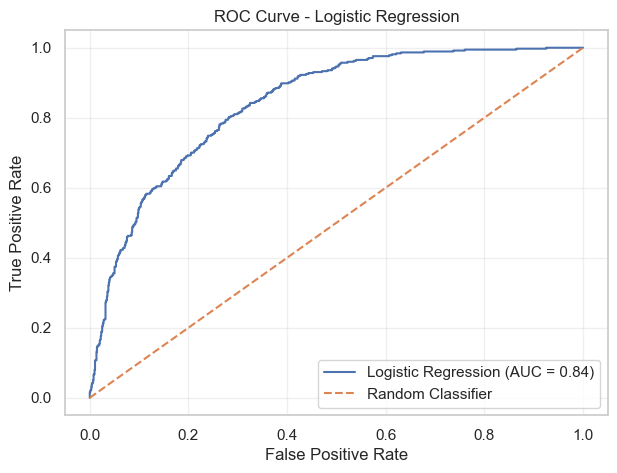

In [43]:
from sklearn.metrics import roc_curve

# Calculate ROC curve
fpr, tpr, thresholds_roc = roc_curve(y_test_encoded, y_prob)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.2f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

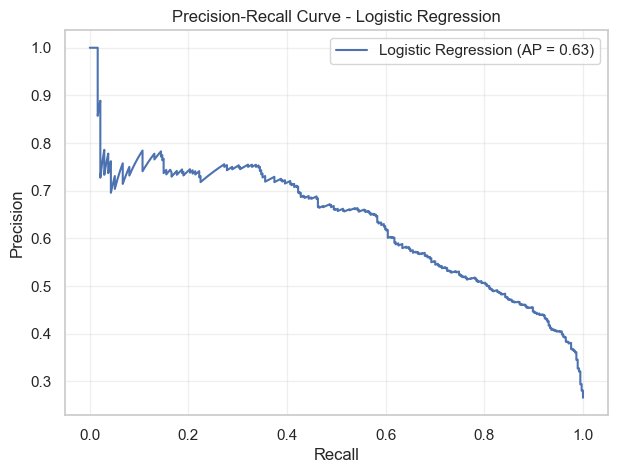

Average Precision (AP): 0.6343


In [44]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Calculate Precision-Recall values
precision_values, recall_values, pr_thresholds = precision_recall_curve(
    y_test_encoded,
    y_prob
)

average_precision = average_precision_score(
    y_test_encoded,
    y_prob
)

plt.figure(figsize=(7, 5))

plt.plot(
    recall_values,
    precision_values,
    label=f"Logistic Regression (AP = {average_precision:.2f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Logistic Regression")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Average Precision (AP): {average_precision:.4f}")

In [45]:
# Get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# Get Logistic Regression coefficients
coefficients = baseline_model.coef_[0]

# Create feature importance DataFrame
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Sort by coefficient
feature_importance = feature_importance.sort_values(
    by="Coefficient",
    ascending=False
)

print("Top 15 features associated with Churn:")
print(feature_importance.head(15))

print("\nTop 15 features associated with No Churn:")
print(feature_importance.tail(15).sort_values("Coefficient"))

Top 15 features associated with Churn:
                                Feature  Coefficient
16     cat__InternetService_Fiber optic     0.634195
36         cat__Contract_Month-to-month     0.582883
3                     num__TotalCharges     0.536253
35             cat__StreamingMovies_Yes     0.200938
32                 cat__StreamingTV_Yes     0.200481
43  cat__PaymentMethod_Electronic check     0.197867
18               cat__OnlineSecurity_No     0.156279
27                  cat__TechSupport_No     0.131503
14               cat__MultipleLines_Yes     0.104649
0                    num__SeniorCitizen     0.053449
21                 cat__OnlineBackup_No     0.033455
40            cat__PaperlessBilling_Yes     0.028672
26            cat__DeviceProtection_Yes     0.021983
24             cat__DeviceProtection_No    -0.036433
8                    cat__Dependents_No    -0.046067

Top 15 features associated with No Churn:
                                      Feature  Coefficient
1          

In [46]:
# Check correlations among numerical features
numerical_corr = df[
    ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]
].corr()

print("Correlation matrix:")
print(numerical_corr.round(3))

Correlation matrix:
                SeniorCitizen  tenure  MonthlyCharges  TotalCharges
SeniorCitizen           1.000   0.017           0.220         0.103
tenure                  0.017   1.000           0.248         0.826
MonthlyCharges          0.220   0.248           1.000         0.651
TotalCharges            0.103   0.826           0.651         1.000


In [47]:
# Compare numerical features by churn status
print("Average numerical values by churn status:")
print(
    df.groupby("Churn")[
        ["tenure", "MonthlyCharges", "TotalCharges"]
    ].mean().round(2)
)

Average numerical values by churn status:
       tenure  MonthlyCharges  TotalCharges
Churn                                      
No      37.57           61.27       2549.91
Yes     17.98           74.44       1531.80


In [48]:
from sklearn.linear_model import LinearRegression

# Numerical features
X_vif = df[
    ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]
].copy()

vif_results = []

for i, feature in enumerate(X_vif.columns):
    X_other = X_vif.drop(columns=[feature])
    y_feature = X_vif[feature]

    model = LinearRegression()
    model.fit(X_other, y_feature)

    r_squared = model.score(X_other, y_feature)

    # VIF = 1 / (1 - R²)
    vif = 1 / (1 - r_squared)

    vif_results.append({
        "Feature": feature,
        "VIF": vif
    })

vif_data = pd.DataFrame(vif_results)

print("Variance Inflation Factor (VIF):")
print(vif_data.round(2))

Variance Inflation Factor (VIF):
          Feature   VIF
0   SeniorCitizen  1.05
1          tenure  5.84
2  MonthlyCharges  3.31
3    TotalCharges  9.53


In [49]:
# Remove TotalCharges due to high multicollinearity
X_reduced = X.drop(columns=["TotalCharges"])

print("Reduced feature set created.")
print("Original features:", X.shape[1])
print("Reduced features:", X_reduced.shape[1])

print("\nRemaining numerical columns:")
print(
    X_reduced.select_dtypes(
        include=["int64", "float64"]
    ).columns.tolist()
)

Reduced feature set created.
Original features: 19
Reduced features: 18

Remaining numerical columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges']


In [50]:
# Identify columns in reduced dataset
reduced_numerical_cols = X_reduced.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

reduced_categorical_cols = X_reduced.select_dtypes(
    include=["object"]
).columns.tolist()

# Create reduced preprocessing pipeline
reduced_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), reduced_numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), reduced_categorical_cols)
    ]
)

# Fit ONLY on training data
X_train_reduced = X_train.drop(columns=["TotalCharges"])
X_test_reduced = X_test.drop(columns=["TotalCharges"])

X_train_reduced_processed = reduced_preprocessor.fit_transform(
    X_train_reduced
)

X_test_reduced_processed = reduced_preprocessor.transform(
    X_test_reduced
)

print("Reduced preprocessing completed.")
print("Training shape:", X_train_reduced_processed.shape)
print("Testing shape:", X_test_reduced_processed.shape)

Reduced preprocessing completed.
Training shape: (5634, 44)
Testing shape: (1409, 44)


In [53]:
# Create reduced Logistic Regression model
lr_reduced = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train
lr_reduced.fit(
    X_train_reduced_processed,
    y_train_encoded
)

print("Reduced Logistic Regression trained successfully.")

Reduced Logistic Regression trained successfully.


In [54]:
# Predictions
lr_reduced_pred = lr_reduced.predict(X_test_reduced_processed)
lr_reduced_prob = lr_reduced.predict_proba(
    X_test_reduced_processed
)[:, 1]

# Metrics
reduced_accuracy = accuracy_score(
    y_test_encoded, lr_reduced_pred
)
reduced_precision = precision_score(
    y_test_encoded, lr_reduced_pred
)
reduced_recall = recall_score(
    y_test_encoded, lr_reduced_pred
)
reduced_f1 = f1_score(
    y_test_encoded, lr_reduced_pred
)
reduced_roc_auc = roc_auc_score(
    y_test_encoded, lr_reduced_prob
)

print("\nReduced Logistic Regression Results")
print("------------------------------------")
print(f"Accuracy : {reduced_accuracy:.4f}")
print(f"Precision: {reduced_precision:.4f}")
print(f"Recall   : {reduced_recall:.4f}")
print(f"F1-Score : {reduced_f1:.4f}")
print(f"ROC-AUC  : {reduced_roc_auc:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_encoded, lr_reduced_pred))


Reduced Logistic Regression Results
------------------------------------
Accuracy : 0.7977
Precision: 0.6378
Recall   : 0.5508
F1-Score : 0.5911
ROC-AUC  : 0.8391

Confusion Matrix:
[[918 117]
 [168 206]]


In [55]:
# Identify original feature types
numerical_cols = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_cols = X.select_dtypes(
    include=["object"]
).columns.tolist()

# Original preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

# Fit ONLY on training data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Original preprocessing rebuilt.")
print("Training shape:", X_train_processed.shape)
print("Testing shape:", X_test_processed.shape)

Original preprocessing rebuilt.
Training shape: (5634, 45)
Testing shape: (1409, 45)


In [56]:
# Train original Logistic Regression
baseline_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

baseline_model.fit(
    X_train_processed,
    y_train_encoded
)

# Test probabilities
y_prob = baseline_model.predict_proba(
    X_test_processed
)[:, 1]

# Default 0.50 predictions
y_pred = (y_prob >= 0.50).astype(int)

# ROC-AUC
roc_auc = roc_auc_score(
    y_test_encoded,
    y_prob
)

print("Original Logistic Regression rebuilt successfully.")
print(f"ROC-AUC: {roc_auc:.4f}")

Original Logistic Regression rebuilt successfully.
ROC-AUC: 0.8421
